# Floor Detection Model Training (YOLOv11)

Trains YOLOv11 (detection, not segmentation) on a custom floor dataset.

We use **detection** because the Roboflow export is ~98% rectangular bbox labels
(only ~2% real polygons). A segmentation head trained on rectangle masks is
capped at low mAP50-95 since "predicted mask" and "ground truth mask" are both
rectangles -- mAP50-95 (box) is the meaningful metric anyway.

**Setup:**
1. Settings → Accelerator → **GPU T4 x2** (or P100)
2. Add Data → attach your uploaded floor dataset
3. Update `DATASET_PATH` below to match your dataset slug

In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.7 MB/s eta 0:00:00


In [3]:
import os, yaml, torch
from ultralytics import YOLO

print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
Device: Tesla T4


In [4]:
# Update this to your Kaggle dataset path (check /kaggle/input/ folder name)
DATASET_PATH = '/kaggle/input/datasets/muhammadwajihhyder/fyp2floorv2/FYP2Floor.v1i.yolov11'

!ls {DATASET_PATH}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [5]:
# Roboflow's data.yaml uses relative paths - patch it to use absolute paths
src_yaml = os.path.join(DATASET_PATH, 'data.yaml')
with open(src_yaml) as f:
    cfg = yaml.safe_load(f)

cfg['path'] = DATASET_PATH
cfg['train'] = 'train/images'
cfg['val']   = 'valid/images'
cfg['test']  = 'test/images'

out_yaml = '/kaggle/working/data.yaml'
with open(out_yaml, 'w') as f:
    yaml.safe_dump(cfg, f)

print(cfg)

{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['floor'], 'roboflow': {'workspace': 'wajihs-workspace-mrwcb', 'project': 'fyp2floor', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/wajihs-workspace-mrwcb/fyp2floor/dataset/1'}, 'path': '/kaggle/input/datasets/muhammadwajihhyder/fyp2floorv2/FYP2Floor.v1i.yolov11'}


## Normalize mixed labels (bbox + polygon) → bbox

YOLO detection needs all labels in bbox format (`cls cx cy w h`). Roboflow's
*Instance Segmentation* export gives mixed bbox-and-polygon files; this cell
collapses every polygon to its axis-aligned bounding box. Images are symlinked
into `/kaggle/working/dataset/`; only labels are rewritten.

In [6]:
import shutil
from pathlib import Path

FIXED_ROOT = Path('/kaggle/working/dataset')
if FIXED_ROOT.exists():
    shutil.rmtree(FIXED_ROOT)

bbox_count = poly_count = 0

for split in ['train', 'valid', 'test']:
    img_src = Path(DATASET_PATH) / split / 'images'
    lbl_src = Path(DATASET_PATH) / split / 'labels'
    img_dst = FIXED_ROOT / split / 'images'
    lbl_dst = FIXED_ROOT / split / 'labels'
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    # symlink images (no copy)
    for p in img_src.iterdir():
        (img_dst / p.name).symlink_to(p)

    # rewrite labels: polygon -> AABB bbox; keep bbox as-is
    for lp in lbl_src.glob('*.txt'):
        out_lines = []
        for line in lp.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                out_lines.append(line)
                bbox_count += 1
            elif len(parts) >= 7:
                cls = parts[0]
                coords = list(map(float, parts[1:]))
                xs, ys = coords[0::2], coords[1::2]
                x_min, x_max = min(xs), max(xs)
                y_min, y_max = min(ys), max(ys)
                cx = (x_min + x_max) / 2
                cy = (y_min + y_max) / 2
                w  = x_max - x_min
                h  = y_max - y_min
                out_lines.append(f'{cls} {cx} {cy} {w} {h}')
                poly_count += 1
        (lbl_dst / lp.name).write_text('\n'.join(out_lines) + '\n')

print(f'Kept {bbox_count} bbox labels as-is')
print(f'Converted {poly_count} polygon labels -> AABB bbox')

# Repoint data.yaml at the fixed dataset
cfg['path'] = str(FIXED_ROOT)
with open(out_yaml, 'w') as f:
    yaml.safe_dump(cfg, f)
print(cfg)

Kept 3918 bbox labels as-is
Converted 97 polygon labels -> AABB bbox
{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['floor'], 'roboflow': {'workspace': 'wajihs-workspace-mrwcb', 'project': 'fyp2floor', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/wajihs-workspace-mrwcb/fyp2floor/dataset/1'}, 'path': '/kaggle/working/dataset'}


## Dataset inspection → hyperparameter tuning

Run the two cells below to (1) print stats with concrete suggestions for `imgsz`, `batch`, and class-weighting, and (2) visualize random training images with their polygon labels overlaid so you can sanity-check label quality before committing to a long training run.

In [7]:
from PIL import Image as PILImage
from collections import Counter
import numpy as np

names = cfg.get('names', {})
if isinstance(names, list):
    names = {i: n for i, n in enumerate(names)}

stats = {}
for split in ['train', 'valid', 'test']:
    img_dir = FIXED_ROOT / split / 'images'
    lbl_dir = FIXED_ROOT / split / 'labels'
    imgs = list(img_dir.iterdir())
    sizes = [PILImage.open(p).size for p in imgs]  # (w, h)
    cls_counter = Counter()
    inst_per_img = []
    obj_area_frac = []  # bbox area / image area (both normalized)
    for lp in lbl_dir.glob('*.txt'):
        lines = lp.read_text().strip().splitlines()
        inst_per_img.append(len(lines))
        for line in lines:
            parts = line.split()
            if len(parts) != 5: continue
            cls_counter[int(parts[0])] += 1
            _, _, _, w, h = parts
            obj_area_frac.append(float(w) * float(h))
    stats[split] = {
        'n_images': len(imgs),
        'n_labels': sum(cls_counter.values()),
        'classes': dict(cls_counter),
        'img_w_median': int(np.median([s[0] for s in sizes])) if sizes else 0,
        'img_h_median': int(np.median([s[1] for s in sizes])) if sizes else 0,
        'inst_per_img_median': float(np.median(inst_per_img)) if inst_per_img else 0,
        'inst_per_img_max': max(inst_per_img) if inst_per_img else 0,
        'obj_area_frac_median': float(np.median(obj_area_frac)) if obj_area_frac else 0,
    }

print('=== Per-split stats ===')
for split, s in stats.items():
    print(f'\n[{split}]')
    for k, v in s.items():
        if k == 'classes':
            named = {names.get(c, c): n for c, n in v.items()}
            print(f'  {k}: {named}')
        else:
            print(f'  {k}: {v}')

# Recommendations
tr = stats['train']
med_dim = max(tr['img_w_median'], tr['img_h_median'])
rec_imgsz = 640 if med_dim <= 800 else (960 if med_dim <= 1100 else 1280)

if tr['inst_per_img_median'] > 10 or tr['obj_area_frac_median'] < 0.02:
    rec_batch = 8  # dense / tiny objects -> smaller batch, higher res
elif tr['inst_per_img_median'] <= 3:
    rec_batch = 16
else:
    rec_batch = 12

counts = list(tr['classes'].values())
imbalanced = len(counts) > 1 and max(counts) / max(min(counts), 1) > 3

print('\n=== Suggested hyperparameters ===')
print(f'imgsz       = {rec_imgsz}   (median image {tr["img_w_median"]}x{tr["img_h_median"]})')
print(f'batch       = {rec_batch}   (median {tr["inst_per_img_median"]:.1f} instances/img, max {tr["inst_per_img_max"]})')
print(f'epochs      = 100  (early-stop via patience=20)')
print(f'mosaic/mixup= keep mosaic=1.0; lower mixup to 0.0 if dataset < ~500 images')
if tr['obj_area_frac_median'] < 0.02:
    print('NOTE: objects are small -> consider imgsz>=960 and scale=0.3 (less aggressive)')
if imbalanced:
    print(f'NOTE: class counts imbalanced ({tr["classes"]}) -> consider adding `cls=1.0` weight or oversampling')

=== Per-split stats ===

[train]
  n_images: 872
  n_labels: 3254
  classes: {'floor': 3254}
  img_w_median: 1031
  img_h_median: 683
  inst_per_img_median: 3.0
  inst_per_img_max: 17
  obj_area_frac_median: 0.18051771248457266

[valid]
  n_images: 109
  n_labels: 395
  classes: {'floor': 395}
  img_w_median: 1076
  img_h_median: 644
  inst_per_img_median: 3.0
  inst_per_img_max: 12
  obj_area_frac_median: 0.1777309596216761

[test]
  n_images: 109
  n_labels: 366
  classes: {'floor': 366}
  img_w_median: 1104
  img_h_median: 710
  inst_per_img_median: 3.0
  inst_per_img_max: 13
  obj_area_frac_median: 0.20583036691894474

=== Suggested hyperparameters ===
imgsz       = 960   (median image 1031x683)
batch       = 16   (median 3.0 instances/img, max 17)
epochs      = 100  (early-stop via patience=20)
mosaic/mixup= keep mosaic=1.0; lower mixup to 0.0 if dataset < ~500 images


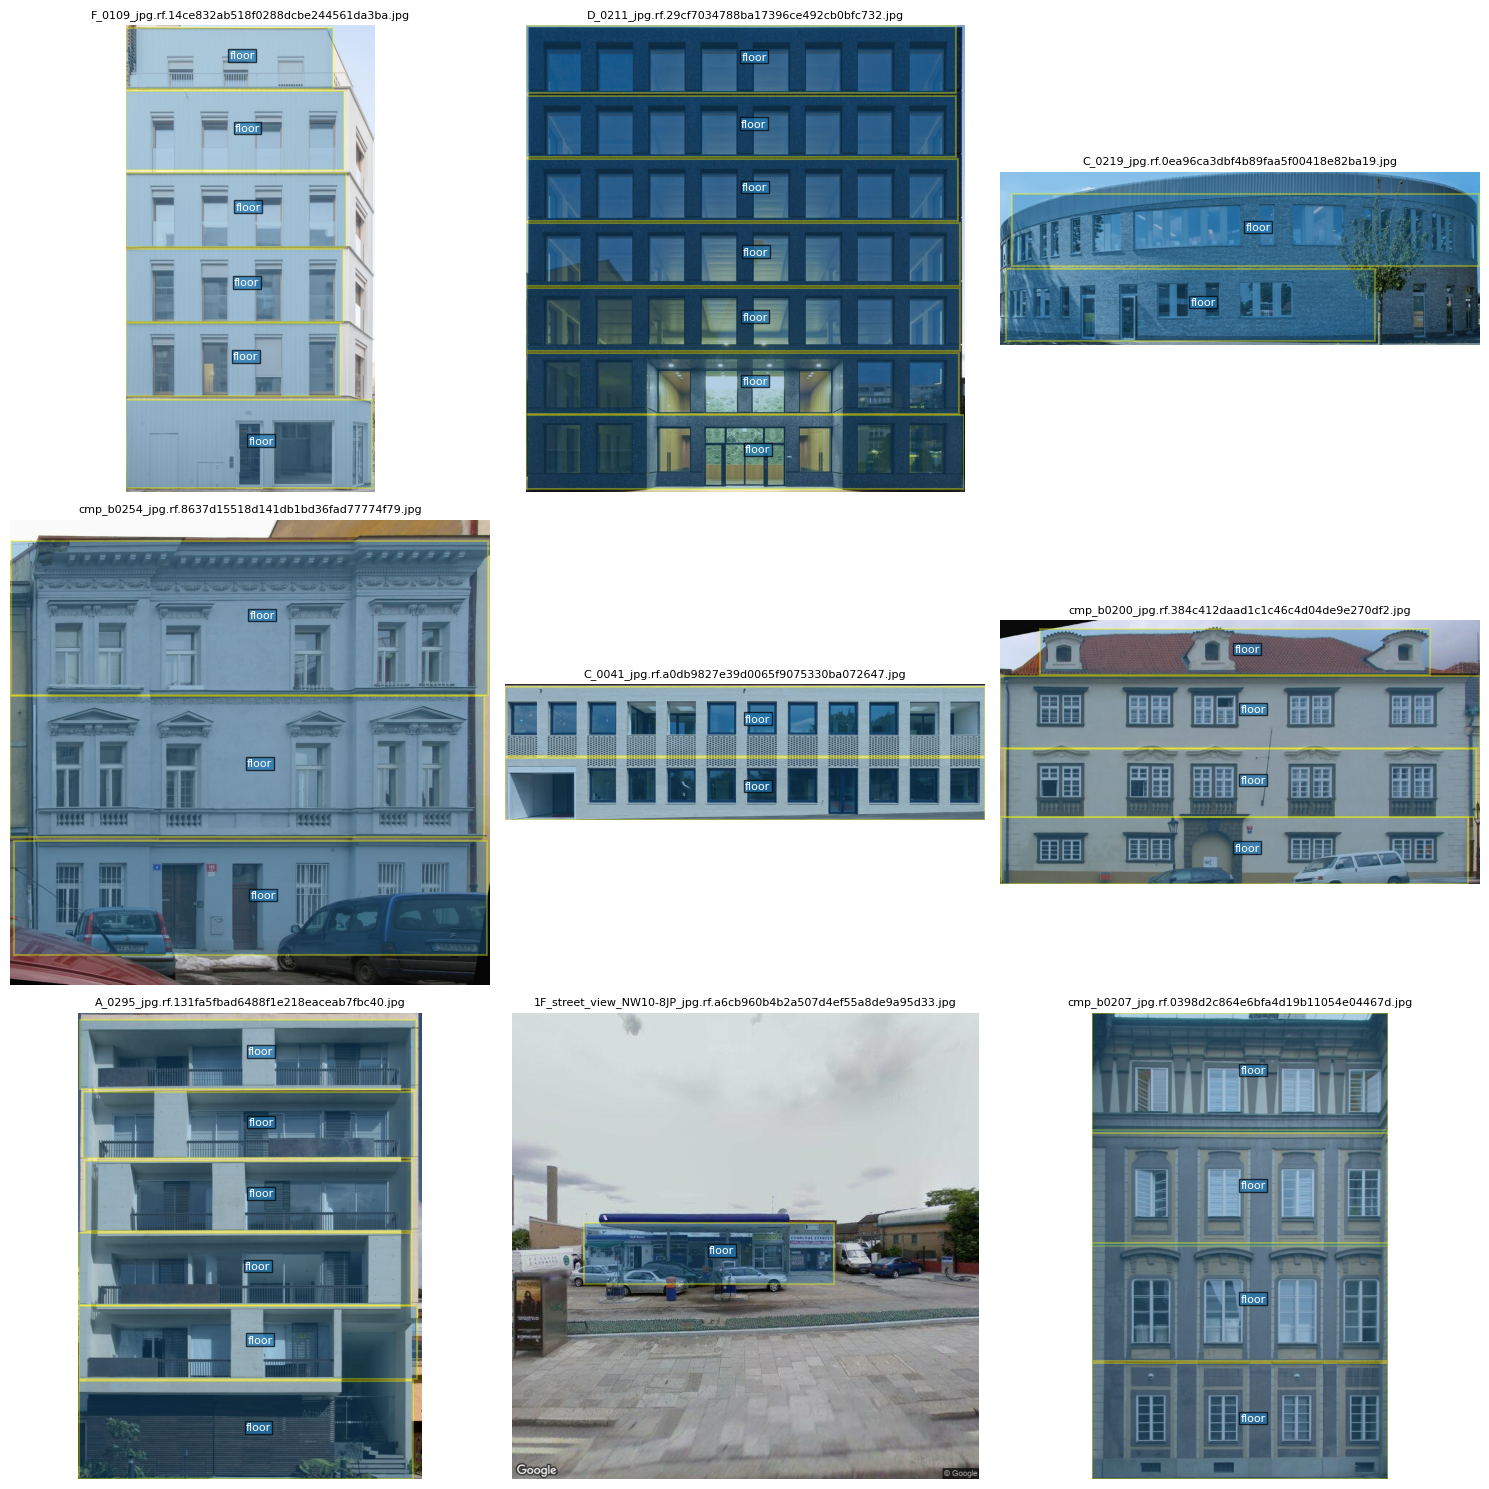

In [8]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_SAMPLES = 9          # how many images to visualize
SPLIT     = 'train'    # 'train' | 'valid' | 'test'

img_dir = FIXED_ROOT / SPLIT / 'images'
lbl_dir = FIXED_ROOT / SPLIT / 'labels'

random.seed(0)
samples = random.sample(list(img_dir.iterdir()), min(N_SAMPLES, len(list(img_dir.iterdir()))))

cols = 3
rows = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

palette = plt.cm.tab10.colors

for ax, img_path in zip(axes, samples):
    img = PILImage.open(img_path)
    W, H = img.size
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')

    lbl_path = lbl_dir / (img_path.stem + '.txt')
    if not lbl_path.exists(): continue

    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5: continue
        cls = int(parts[0])
        cx, cy, w, h = map(float, parts[1:])
        x = (cx - w/2) * W
        y = (cy - h/2) * H
        rect = mpatches.Rectangle((x, y), w*W, h*H,
                                  linewidth=1.5,
                                  edgecolor='yellow',
                                  facecolor=palette[cls % len(palette)],
                                  alpha=0.35)
        ax.add_patch(rect)
        ax.text(cx*W, cy*H, names.get(cls, str(cls)), color='white', fontsize=8,
                bbox=dict(facecolor=palette[cls % len(palette)], alpha=0.7, pad=1))

for ax in axes[len(samples):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Pre-flight audit (predict whether 90% mAP@50 is reachable)

Runs cheap checks that correlate strongly with final mAP. A clean PASS doesn't guarantee 90%, but FAILs cap your ceiling — fix them before the full training run.

Checks: (1) min samples per class, (2) class imbalance, (3) train/val distribution shift, (4) images with no labels, (5) suspicious tiny polygons (likely mislabels), (6) total training-set size.

In [9]:
issues = []

# 1. min samples per class
MIN_PER_CLASS = 100
for cls, n in stats['train']['classes'].items():
    name = names.get(cls, cls)
    if n < MIN_PER_CLASS:
        issues.append(f'FAIL: class "{name}" has only {n} train instances (<{MIN_PER_CLASS}). Expect <90% mAP for this class.')
    elif n < 200:
        issues.append(f'WARN: class "{name}" has {n} train instances. 200+ recommended for robust 90% mAP.')

# 2. class imbalance
counts = list(stats['train']['classes'].values())
if len(counts) > 1:
    ratio = max(counts) / max(min(counts), 1)
    if ratio > 5:
        issues.append(f'WARN: class imbalance {ratio:.1f}x. Minority class will underperform unless reweighted.')

# 3. train/val distribution shift
if stats['valid']['classes']:
    tot_t = sum(stats['train']['classes'].values())
    tot_v = max(sum(stats['valid']['classes'].values()), 1)
    for c in set(stats['train']['classes']) | set(stats['valid']['classes']):
        td = stats['train']['classes'].get(c, 0) / tot_t
        vd = stats['valid']['classes'].get(c, 0) / tot_v
        if abs(td - vd) > 0.15:
            issues.append(f'WARN: class "{names.get(c, c)}" distribution shift: train={td:.2f} vs val={vd:.2f}.')

# 4. empty labels
empty = []
for split in ['train', 'valid']:
    for ip in (FIXED_ROOT / split / 'images').iterdir():
        lp = FIXED_ROOT / split / 'labels' / (ip.stem + '.txt')
        if not lp.exists() or not lp.read_text().strip():
            empty.append(f'{split}/{ip.name}')
if empty:
    issues.append(f'WARN: {len(empty)} images have no labels (trained as background). First 5: {empty[:5]}')

# 5. tiny boxes (likely mislabels)
tiny = 0
for lp in (FIXED_ROOT / 'train' / 'labels').glob('*.txt'):
    for line in lp.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5: continue
        _, _, _, w, h = parts
        if float(w) * float(h) < 0.001:
            tiny += 1
if tiny > 0:
    issues.append(f'WARN: {tiny} boxes have area <0.1% of image -- likely mislabels. Inspect them.')

# 6. dataset size
n_train = stats['train']['n_images']
if n_train < 500:
    issues.append(f'WARN: only {n_train} training images. 90% mAP@50 typically needs 800+ for multi-class.')

print('=== Pre-flight audit ===\n')
if not issues:
    print('PASS: no critical issues detected.')
else:
    for i in issues:
        print('  -', i)
print(f'\nFlags: {sum(1 for i in issues if i.startswith("FAIL"))} FAIL, '
      f'{sum(1 for i in issues if i.startswith("WARN"))} WARN')
print('\nFix FAILs before training. WARNs usually OK but lower your ceiling.')

=== Pre-flight audit ===

PASS: no critical issues detected.

Flags: 0 FAIL, 0 WARN

Fix FAILs before training. WARNs usually OK but lower your ceiling.


## Smoke test (predict final mAP@50 in ~5-10 min)

Trains the smallest model (`yolo11n-seg`) for 15 epochs. This is the most reliable predictor of whether 90% is reachable:

| Smoke val mAP@50 | Projection for full run |
|---|---|
| ≥ 0.75 | On track for 90%+ |
| 0.55-0.75 | 75-85% likely — try larger model, more epochs, or label review |
| < 0.55 | Audit labels & class balance before committing |

Why this works: floor segmentation converges fast. If a tiny model with 15 epochs is already in striking distance, a larger model trained 100 epochs will close the gap.

In [10]:
import pandas as pd

smoke = YOLO('yolo11n.pt')
smoke.train(
    data=out_yaml,
    task='detect',
    epochs=15,
    imgsz=rec_imgsz,
    batch=rec_batch,
    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,
    project='/kaggle/working/runs',
    name='smoke_test',
    device=0,
    workers=4,
    seed=42,
    plots=False,
    verbose=False,
)

df = pd.read_csv('/kaggle/working/runs/smoke_test/results.csv')
df.columns = [c.strip() for c in df.columns]
print(df[['epoch', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail(5).to_string(index=False))

last = df['metrics/mAP50(B)'].iloc[-1]
print(f'\nSmoke test final mAP@50 (box): {last:.3f}')

if last >= 0.75:
    print('PROJECTION: on track for 90%+ with full training. Proceed.')
elif last >= 0.55:
    print('PROJECTION: 75-85% likely. Consider yolo11m / yolo11l, more epochs, or label review.')
else:
    print('PROJECTION: <70% likely. Audit labels and class balance before committing to a long run.')

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smoke_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, 

In [11]:
# yolo11l = best detection accuracy that fits comfortably on 2x T4 at imgsz=960.
# yolo11x has marginally higher ceiling but risks OOM at this resolution and
# tends to overfit on ~1k images -- L is the practical sweet spot.
model = YOLO('yolo11l.pt')

results = model.train(
    data=out_yaml,
    task='detect',
    epochs=150,
    imgsz=960,
    batch=16,                # total across both GPUs -> 8 per GPU
    patience=30,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3,
    close_mosaic=15,         # disable mosaic in last 15 epochs -> cleaner convergence
    augment=True,
    mosaic=1.0,
    mixup=0.10,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10, translate=0.1, scale=0.5, fliplr=0.5,
    project='/kaggle/working/runs',
    name='floor_yolo11l_det',
    device=[0, 1],           # both T4s
    workers=8,
    seed=42,
)

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=floor_yolo11l_det, nbs=64

In [13]:
# Evaluate on the test split -- imgsz MUST match training (960) or you lose
# 2-5 mAP points to resolution mismatch. Keep conf low for mAP computation.
metrics = model.val(data=out_yaml, split='test', imgsz=960, conf=0.001, iou=0.6)
print('mAP50:    ', metrics.box.map50)
print('mAP50-95: ', metrics.box.map)

Ultralytics 8.4.49 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 201.7±145.3 MB/s, size: 209.6 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 109 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 109/109 41.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2s/it 8.1s1.5ss
                   all        109        366      0.906      0.897      0.933      0.629
Speed: 1.8ms preprocess, 64.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
mAP50:     0.9328993935487958
mAP50-95:  0.6294836427971758



0: 960x960 5 floors, 83.8ms
1: 960x960 2 floors, 83.8ms
2: 960x960 2 floors, 83.8ms
3: 960x960 6 floors, 83.8ms
4: 960x960 2 floors, 83.8ms
5: 960x960 6 floors, 83.8ms
Speed: 4.7ms preprocess, 83.8ms inference, 1.0ms postprocess per image at shape (1, 3, 960, 960)
Results saved to /kaggle/working/runs/preds-3


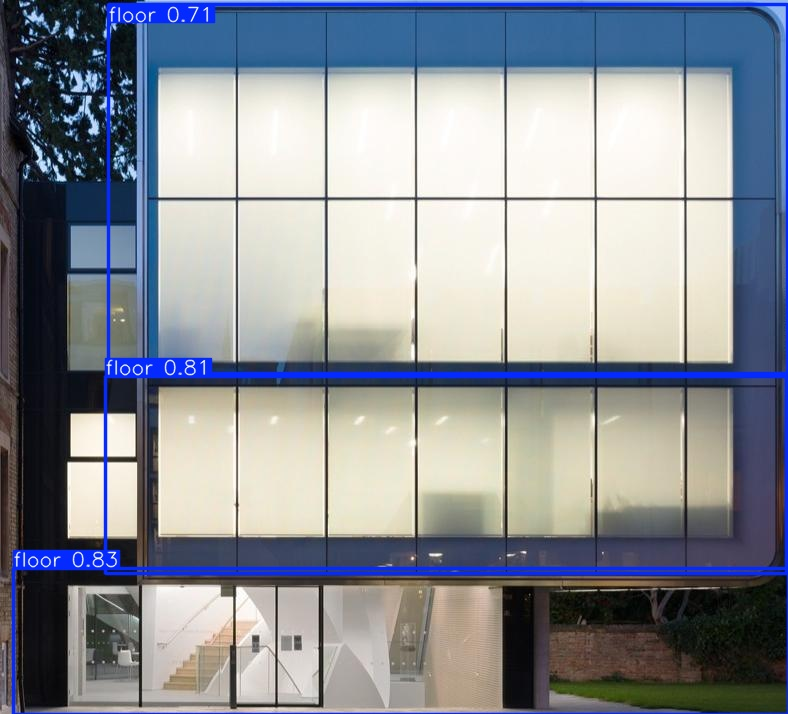

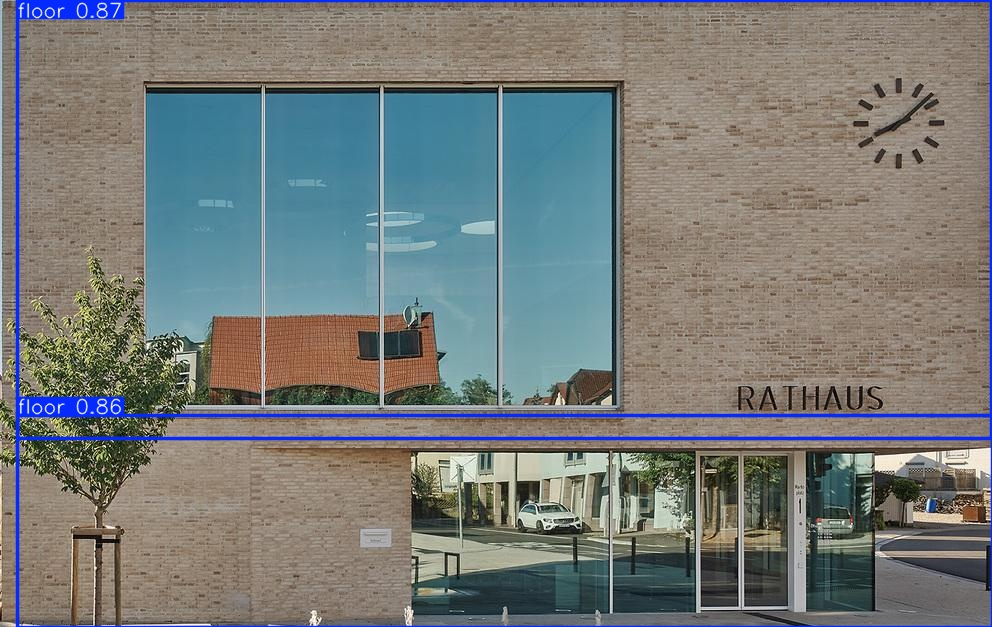

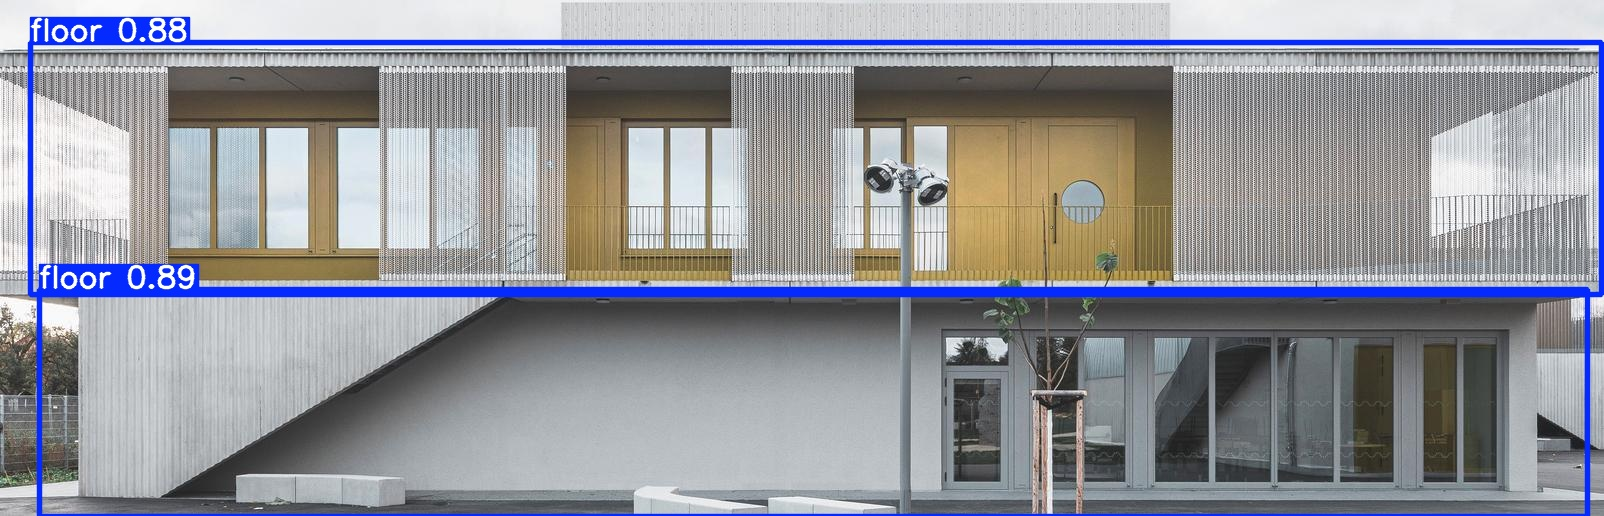

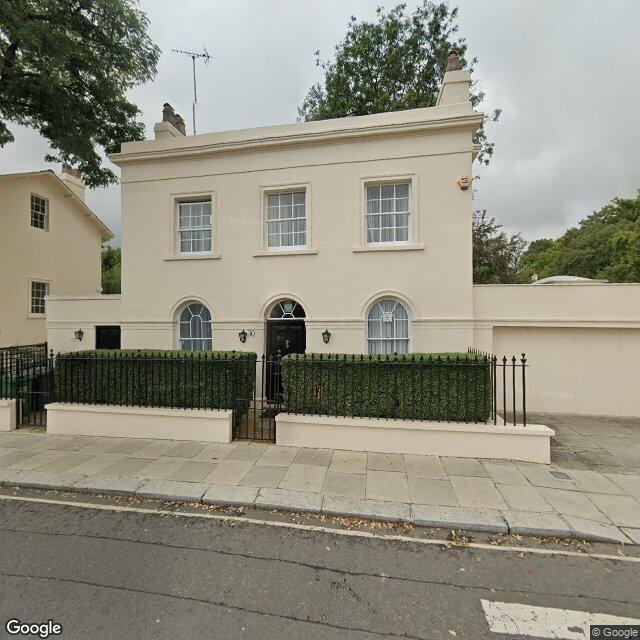

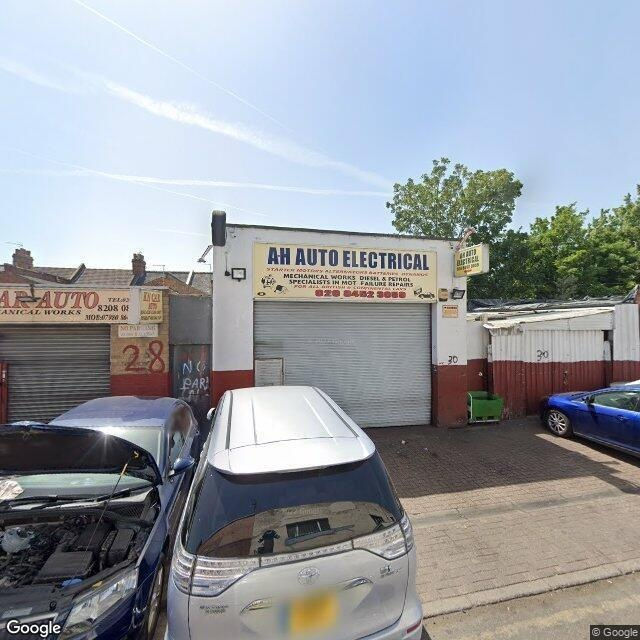

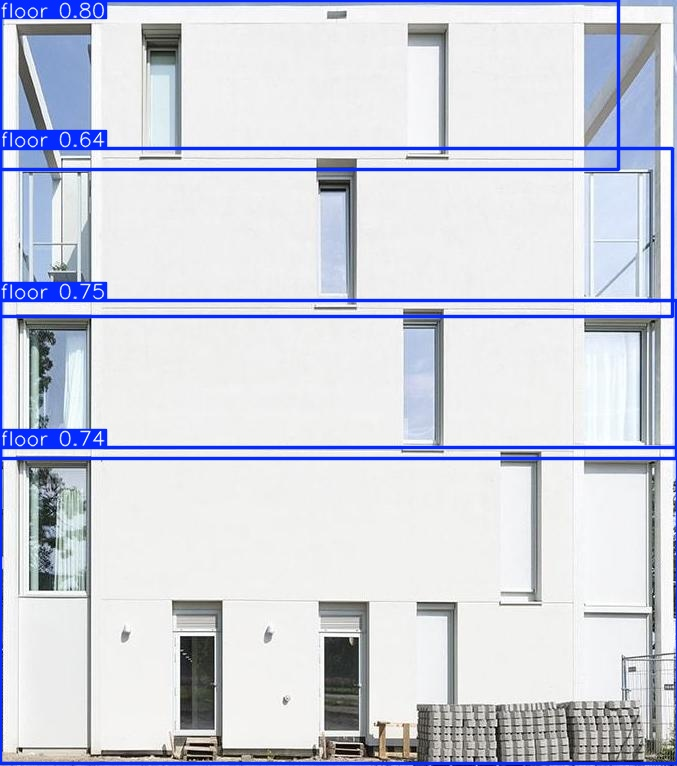

In [17]:
# Sanity-check predictions. Inference settings tuned for stacked-floor case:
#   imgsz=960  -> match training resolution
#   conf=0.5   -> drop low-confidence phantoms (e.g. the floor_0.30 box)
#   iou=0.4    -> stricter NMS, suppress stacked-floor duplicates that the
#                 default iou=0.7 lets through
import glob
test_imgs = glob.glob(f'{DATASET_PATH}/test/images/*')[:6]
preds = model.predict(test_imgs, imgsz=960, conf=0.1, iou=0.8, save=True,
                       project='/kaggle/working/runs', name='preds')

from IPython.display import Image, display
for p in glob.glob('/kaggle/working/runs/preds/*.jpg')[:6]:
    display(Image(p))

In [18]:
# Per-image diagnostic: GT count + max prediction confidence at conf=0.001.
# Run this when specific images show "no detections" -- it distinguishes
# between labeling problems and model failures.
from pathlib import Path
import glob

test_imgs = sorted(glob.glob(f'{DATASET_PATH}/test/images/*'))[:6]

print(f"{'image':<48} {'GT':>4} {'preds@0.001':>12} {'max_conf':>10}")
print('-' * 80)
for img_path in test_imgs:
    name = Path(img_path).name
    stem = Path(img_path).stem

    gt_path = FIXED_ROOT / 'test' / 'labels' / f'{stem}.txt'
    n_gt = 0
    if gt_path.exists() and gt_path.read_text().strip():
        n_gt = len(gt_path.read_text().strip().splitlines())

    r = model.predict(img_path, imgsz=960, conf=0.001, iou=0.6, verbose=False)[0]
    n_pred = len(r.boxes)
    max_conf = float(r.boxes.conf.max()) if n_pred > 0 else 0.0

    print(f'{name[:47]:<48} {n_gt:>4} {n_pred:>12} {max_conf:>10.4f}')

print()
print('Interpretation:')
print('  GT=0 + preds=0       -> correct (no floors labelled in image)')
print('  GT>0 + preds=0       -> model failure (truly broken for this image)')
print('  GT>0 + max_conf<0.25 -> model finds floors but low confidence (OOD)')
print('  GT=0 + preds>0       -> false positives')

image                                              GT  preds@0.001   max_conf
--------------------------------------------------------------------------------
1F_street_view_NW10-6EU_jpg.rf.e0e6a9656a2187f0     1           49     0.2634
1F_street_view_NW10-6HJ_jpg.rf.3630868cd7207846     1           40     0.7588
1F_street_view_NW10-7AH_jpg.rf.ff04e8e84d17e8db     1           43     0.3629
1F_street_view_NW10-7PF_jpg.rf.c16e3e18e5edbb6d     1           31     0.7738
1F_street_view_NW2-6RX_jpg.rf.882aebc0cc508e6e8     1           56     0.1573
2F_street_view_NW10-4BG_jpg.rf.dd201e204ec1da70     2           27     0.7512

Interpretation:
  GT=0 + preds=0       -> correct (no floors labelled in image)
  GT>0 + preds=0       -> model failure (truly broken for this image)
  GT>0 + max_conf<0.25 -> model finds floors but low confidence (OOD)
  GT=0 + preds>0       -> false positives


In [ ]:
# Export weights for download (Kaggle: right-side panel → /kaggle/working)
best = '/kaggle/working/runs/floor_yolo11l_det/weights/best.pt'
print('Best weights:', best)

# Optional: export to ONNX for deployment (match training imgsz)
# YOLO(best).export(format='onnx', imgsz=960)

In [14]:
import shutil

# This creates '/kaggle/working/floor_yolo11l_det.zip'
shutil.make_archive('/kaggle/working/floor_yolo11l_det', 'zip', '/kaggle/working/runs/floor_yolo11l_det')

'/kaggle/working/floor_yolo11l_det.zip'